In [10]:
# MCP algorithm: 
# First inspect what the data looks like 
from pathlib import Path
import pandas as pd
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

DATAPATH = "/Users/sebastianodutola/Projects/Carbon_Intensity/Data/daily/{day}.parquet"
df = pd.read_parquet(DATAPATH.format(day="2025-01-01"))
df[0:50]


,issued_at,period_start,period_end,forecast,actual
0,2025-01-01 00:00:00+00:00,2024-12-31 23:30:00+00:00,2025-01-01 00:00:00+00:00,53,51
1,2025-01-01 00:00:00+00:00,2025-01-01 00:00:00+00:00,2025-01-01 00:30:00+00:00,49,55
2,2025-01-01 00:00:00+00:00,2025-01-01 00:30:00+00:00,2025-01-01 01:00:00+00:00,52,54
3,2025-01-01 00:00:00+00:00,2025-01-01 01:00:00+00:00,2025-01-01 01:30:00+00:00,56,53
4,2025-01-01 00:00:00+00:00,2025-01-01 01:30:00+00:00,2025-01-01 02:00:00+00:00,53,53
5,2025-01-01 00:00:00+00:00,2025-01-01 02:00:00+00:00,2025-01-01 02:30:00+00:00,53,47
6,2025-01-01 00:00:00+00:00,2025-01-01 02:30:00+00:00,2025-01-01 03:00:00+00:00,52,45
7,2025-01-01 00:00:00+00:00,2025-01-01 03:00:00+00:00,2025-01-01 03:30:00+00:00,48,44
8,2025-01-01 00:00:00+00:00,2025-01-01 03:30:00+00:00,2025-01-01 04:00:00+00:00,44,44
9,2025-01-01 00:00:00+00:00,2025-01-01 04:00:00+00:00,2025-01-01 04:30:00+00:00,44,45


In [ ]:
from datetime import datetime, time, date, timedelta
import numpy as np
import pandas as pd
from battery import Discharge, Load, CarbonTS, merge, lp_optimal
from typing import Callable


def recurring_discharge(times: list[tuple[time, time, float]], start: datetime, window: timedelta) -> list[Discharge]:
    end = start + window
    discharges = []
    d = start.date()
    while d <= end.date():
        for t_start, t_end, power in times:
            dt_start = datetime.combine(d, t_start)
            dt_end = datetime.combine(d, t_end)
            # Case 1 start in a discharge period:
            if dt_start < start < dt_end:
                discharges.append(Discharge(np.datetime64(start), np.datetime64(min(dt_end, end)), power))
            # Case 2 start not in a discharge period:
            if start <= dt_start < end:
                discharges.append(Discharge(np.datetime64(dt_start), np.datetime64(min(dt_end, end)), power))
        d += timedelta(days=1)
    return discharges

def recurring_availability(times: list[tuple[time,time]], start: datetime, window: timedelta) -> np.ndarray:
    end = start + window
    available = []
    d = start.date()
    while d <= end.date():
        for t_start, t_end in times:
            dt_start = datetime.combine(d, t_start)
            dt_end = datetime.combine(d, t_end)
            # Case 1 start in an available slot
            if dt_start < start < dt_end:
                available.append((np.datetime64(start), np.datetime64(min(dt_end, end))))
            # Case 2 start not in slot.
            if start <= dt_start < end:
                available.append((np.datetime64(dt_start), np.datetime64(min(dt_end, end))))
        d += timedelta(days=1)
    return np.array(available) 


def forecast_range(start: date, end: date):
    curr = datetime.combine(start, time.min)
    df = pd.read_parquet(DATAPATH.format(day=curr.date()))
    while curr.date() <= end:
        yield curr, df[df["issued_at"] == pd.Timestamp(curr, tz="UTC")]
        curr += timedelta(minutes=30)
        if curr.time() == time(0, 0) and curr.date() <= end:
            df = pd.read_parquet(DATAPATH.format(day=curr.date()))


def MCP(
    start: date,
    end: date,
    optimiser: Callable,
    schedule: list[tuple[time, time, float]], # daily discharge periods
    availablility: list[tuple[time,time]], # daily availability periods 
    capacity: float,
    charging_rate: float,
    efficiency: float = 1.0,
    initial_charge: float = 0.0,
) -> pd.DataFrame:
    x = initial_charge
    S = charging_rate * efficiency
    SI = np.timedelta64(30, "m")

    load = Load(
        capacity=capacity,
        charging_rate=charging_rate,
        discharges=[],
        efficiency=efficiency,
        initial_charge=x,
    )

    history = []

    for curr, f in forecast_range(start, end):
        curr_ts = pd.Timestamp(curr, tz="UTC")
        next_ts = curr_ts + pd.Timedelta("30min")

        load.discharges = recurring_discharge(schedule, curr, timedelta(hours=24))
        load.availability = recurring_availability(availablility, curr, timedelta(hours=24))
        load.initial_charge = x

        fwd = f[f["period_start"] >= curr_ts]
        carbon_ts = CarbonTS(
            time=fwd["period_start"].dt.tz_localize(None).to_numpy().astype("datetime64[m]"),
            settlement_interval=SI,
            intensity=fwd["forecast"].to_numpy(dtype=float),
        )

        ts = merge(load, carbon_ts)
        result = optimiser(x, load, ts)
        u = result[0] if result is not None else np.zeros(ts.delta.size)

        step_mask = ts.t < next_ts.to_datetime64()
        energy_charged = 0.0
        for i in np.where(step_mask)[0]:
            dx = S * u[i] * ts.delta[i] - ts.d[i] * ts.delta[i]
            x = float(np.clip(x + dx, 0.0, capacity))
            energy_charged += S * u[i] * ts.delta[i]

        actual_row = f[f["period_start"] == curr_ts]
        actual_intensity = float(actual_row["actual"].iloc[0]) if len(actual_row) > 0 else 0.0

        history.append({
            "t": curr,
            "charge": x,
            "u": float(u[0]) if len(u) > 0 else 0.0,
            "actual_intensity": actual_intensity,
            "actual_cost_gco2": actual_intensity * energy_charged,
        })

    return pd.DataFrame(history)


In [3]:
from battery import greedy_optimal
# Test: EV-like load over 3 days (2025-01-06 to 2025-01-08)
schedule = [
    (time(7, 30), time(9, 30), 5.0),   # morning commute  5 kW for 1h
    (time(17, 30), time(19, 30), 5.0), # evening commute  5 kW for 1h
]

availability = [
    (time(0,0), time(7,30)),
    (time(9,30), time(17, 30)),
    (time(19, 30), time(23,59,59,59))
]

result = MCP(
    start=date(2025, 1, 1),
    end=date(2025, 3, 10),
    optimiser=greedy_optimal,
    schedule=schedule,
    availablility=availability,
    capacity=40.0,
    charging_rate=7.0,
    efficiency=0.95,
    initial_charge=0.0,
)

print(f"Steps: {len(result)}, Total carbon cost: {result['actual_cost_gco2'].sum():.1f} gCO2eq")


Steps: 3312, Total carbon cost: 159527.8 gCO2eq


In [4]:
%%timeit
result_greedy = MCP(
    start=date(2025, 1, 1),
    end=date(2025, 2, 1),
    optimiser=greedy_optimal,
    schedule=schedule,
    availablility=availability,
    capacity=40.0,
    charging_rate=7.0,
    efficiency=0.95,
    initial_charge=0.0,
)

1.68 s ± 56.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [5]:
%%timeit
result_lp = MCP(
    start=date(2025, 1, 1),
    end=date(2025, 2, 1),
    optimiser=lp_optimal,
    schedule=schedule,
    availablility=availability,
    capacity=40.0,
    charging_rate=7.0,
    efficiency=0.95,
    initial_charge=0.0,
)

4.35 s ± 93.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [6]:
result_greedy = MCP(
    start=date(2025, 1, 1),
    end=date(2025, 2, 1),
    optimiser=greedy_optimal,
    schedule=schedule,
    availablility=availability,
    capacity=40.0,
    charging_rate=7.0,
    efficiency=0.95,
    initial_charge=0.0,
)
result_lp = MCP(
    start=date(2025, 1, 1),
    end=date(2025, 2, 1),
    optimiser=lp_optimal,
    schedule=schedule,
    availablility=availability,
    capacity=40.0,
    charging_rate=7.0,
    efficiency=0.95,
    initial_charge=0.0,
)
total_carbon_difference = result_greedy['actual_cost_gco2'].sum() - result_lp['actual_cost_gco2'].sum()
print(f"carbon_difference: {total_carbon_difference}")

carbon_difference: -771.9778346411767


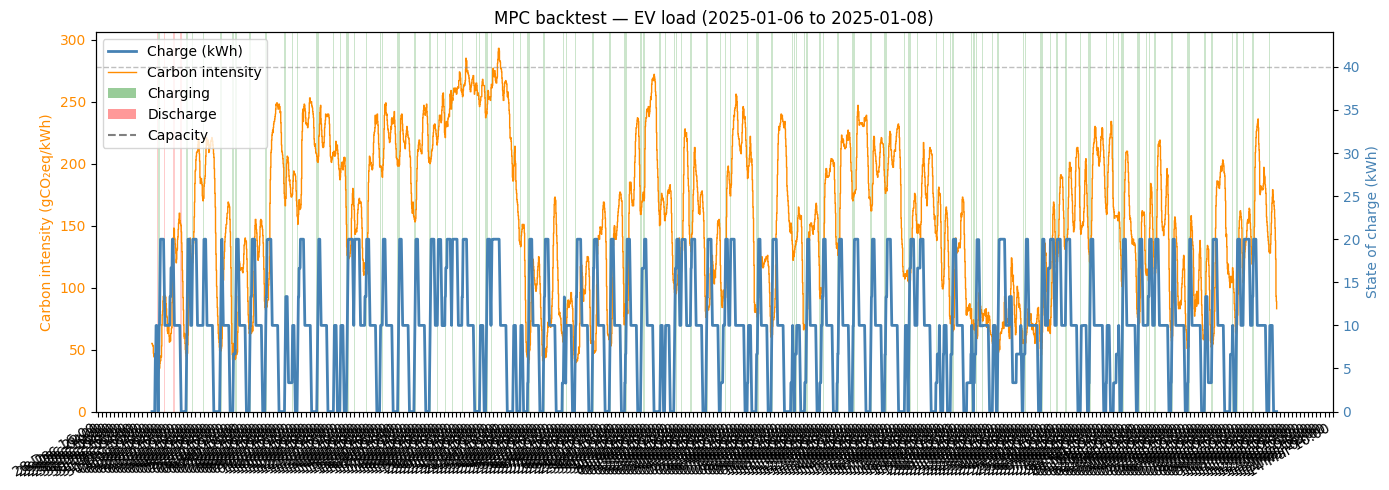

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

t = pd.to_datetime(result["t"])
half_hour = pd.Timedelta("30min")

fig, ax1 = plt.subplots(figsize=(14, 5))

# ── Carbon intensity (left axis) ─────────────────────────────────────────────
ax1.step(t, result["actual_intensity"], where="post",
         color="darkorange", linewidth=1, label="Carbon intensity")
ax1.set_ylabel("Carbon intensity (gCO₂eq/kWh)", color="darkorange")
ax1.tick_params(axis="y", labelcolor="darkorange")
ax1.set_ylim(0, None)

# ── Charge state (right axis) ─────────────────────────────────────────────────
ax2 = ax1.twinx()
ax2.plot(t, result["charge"], color="steelblue", linewidth=2)
ax2.axhline(40.0, color="grey", linestyle="--", linewidth=1, alpha=0.5)
ax2.set_ylabel("State of charge (kWh)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")
ax2.set_ylim(0, 44)

# ── Charging periods (green) ──────────────────────────────────────────────────
for i in result.index[result["u"] > 1e-6]:
    ax1.axvspan(t[i] - half_hour, t[i], alpha=0.2, color="green", linewidth=0)

# ── Discharge periods (red) ───────────────────────────────────────────────────
for day_offset in range(2):
    for t_start, t_end, _ in schedule:
        d = date(2025, 1, 1) + timedelta(days=day_offset)
        ax1.axvspan(
            pd.Timestamp(datetime.combine(d, t_start)),
            pd.Timestamp(datetime.combine(d, t_end)),
            alpha=0.2, color="red", linewidth=0,
        )

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %H:%M"))
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=6))
fig.autofmt_xdate()

legend = [
    plt.Line2D([0], [0], color="steelblue", linewidth=2, label="Charge (kWh)"),
    plt.Line2D([0], [0], color="darkorange", linewidth=1, label="Carbon intensity"),
    mpatches.Patch(facecolor="green", alpha=0.4, label="Charging"),
    mpatches.Patch(facecolor="red",   alpha=0.4, label="Discharge"),
    plt.Line2D([0], [0], color="grey", linestyle="--", label="Capacity"),
]
ax1.legend(handles=legend, loc="upper left")
ax1.set_title("MPC backtest — EV load (2025-01-06 to 2025-01-08)")
plt.tight_layout()
plt.show()


In [ ]:
from battery import lp_naive

def MCP_naive(
    start: date,
    end: date,
    schedule: list[tuple[time, time, float]], # daily discharge periods
    availablility: list[tuple[time,time]], # daily availability periods 
    capacity: float,
    charging_rate: float,
    efficiency: float = 1.0,
    initial_charge: float = 0.0,
) -> pd.DataFrame:
    x = initial_charge
    S = charging_rate * efficiency
    SI = np.timedelta64(30, "m")

    load = Load(
        capacity=capacity,
        charging_rate=charging_rate,
        discharges=[],
        efficiency=efficiency,
        initial_charge=x,
    )

    history = []

    for curr, f in forecast_range(start, end):
        curr_ts = pd.Timestamp(curr, tz="UTC")
        next_ts = curr_ts + pd.Timedelta("30min")

        load.discharges = recurring_discharge(schedule, curr, timedelta(hours=24))
        load.availability = recurring_availability(availablility, curr, timedelta(hours=24))
        load.initial_charge = x

        fwd = f[f["period_start"] >= curr_ts]
        carbon_ts = CarbonTS(
            time=fwd["period_start"].dt.tz_localize(None).to_numpy().astype("datetime64[m]"),
            settlement_interval=SI,
            intensity=fwd["forecast"].to_numpy(dtype=float),
        )

        ts = merge(load, carbon_ts)
        result = lp_naive(x, load, ts)
        u = result[0] if result is not None else np.zeros(ts.delta.size)

        step_mask = ts.t < next_ts.to_datetime64()
        energy_charged = 0.0
        for i in np.where(step_mask)[0]:
            dx = S * u[i] * ts.delta[i] - ts.d[i] * ts.delta[i]
            x = float(np.clip(x + dx, 0.0, capacity))
            energy_charged += S * u[i] * ts.delta[i]

        actual_row = f[f["period_start"] == curr_ts]
        actual_intensity = float(actual_row["actual"].iloc[0]) if len(actual_row) > 0 else 0.0

        history.append({
            "t": curr,
            "charge": x,
            "u": float(u[0]) if len(u) > 0 else 0.0,
            "actual_intensity": actual_intensity,
            "actual_cost_gco2": actual_intensity * energy_charged,
        })

    return pd.DataFrame(history)

result_naive = MCP_naive(
    start=date(2025, 1, 1),
    end=date(2025, 3, 10),
    schedule=schedule,
    availablility=availability,
    capacity=40.0,
    charging_rate=7.0,
    efficiency=0.95,
    initial_charge=0.0,
)

print(f"Steps: {len(result_naive)}, Total carbon cost: {result_naive['actual_cost_gco2'].sum():.1f} gCO2eq")

Steps: 3312, Total carbon cost: 230623.5 gCO2eq


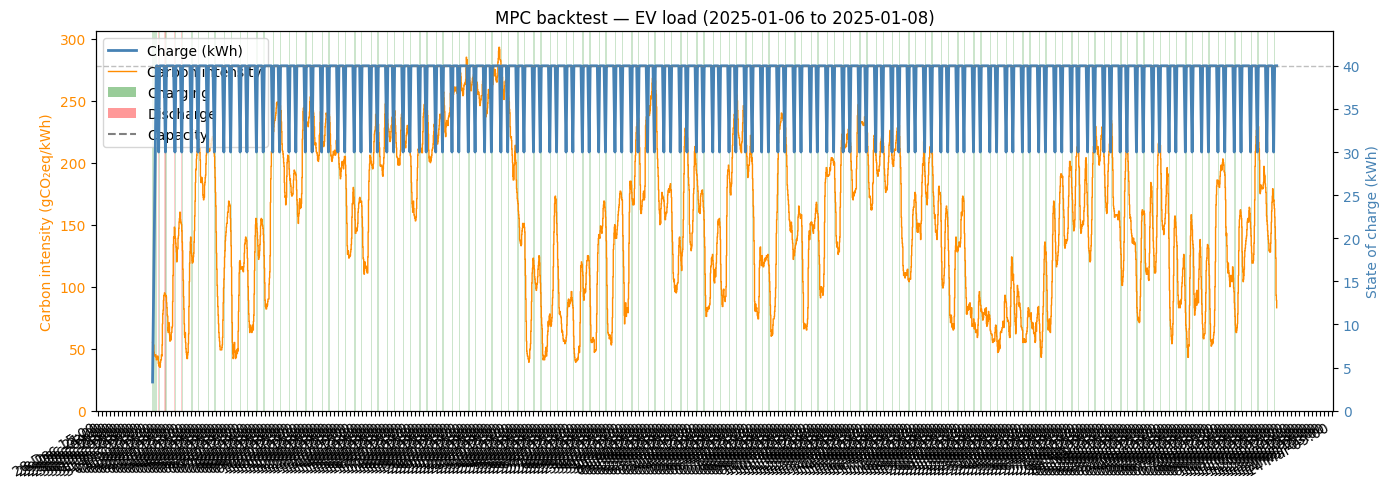

In [9]:
t = pd.to_datetime(result_naive["t"])
half_hour = pd.Timedelta("30min")

fig, ax1 = plt.subplots(figsize=(14, 5))

# ── Carbon intensity (left axis) ─────────────────────────────────────────────
ax1.step(t, result_naive["actual_intensity"], where="post",
         color="darkorange", linewidth=1, label="Carbon intensity")
ax1.set_ylabel("Carbon intensity (gCO₂eq/kWh)", color="darkorange")
ax1.tick_params(axis="y", labelcolor="darkorange")
ax1.set_ylim(0, None)

# ── Charge state (right axis) ─────────────────────────────────────────────────
ax2 = ax1.twinx()
ax2.plot(t, result_naive["charge"], color="steelblue", linewidth=2)
ax2.axhline(40.0, color="grey", linestyle="--", linewidth=1, alpha=0.5)
ax2.set_ylabel("State of charge (kWh)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")
ax2.set_ylim(0, 44)

# ── Charging periods (green) ──────────────────────────────────────────────────
for i in result_naive.index[result_naive["u"] > 1e-6]:
    ax1.axvspan(t[i] - half_hour, t[i], alpha=0.2, color="green", linewidth=0)

# ── Discharge periods (red) ───────────────────────────────────────────────────
for day_offset in range(2):
    for t_start, t_end, _ in schedule:
        d = date(2025, 1, 1) + timedelta(days=day_offset)
        ax1.axvspan(
            pd.Timestamp(datetime.combine(d, t_start)),
            pd.Timestamp(datetime.combine(d, t_end)),
            alpha=0.2, color="red", linewidth=0,
        )

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %H:%M"))
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=6))
fig.autofmt_xdate()

legend = [
    plt.Line2D([0], [0], color="steelblue", linewidth=2, label="Charge (kWh)"),
    plt.Line2D([0], [0], color="darkorange", linewidth=1, label="Carbon intensity"),
    mpatches.Patch(facecolor="green", alpha=0.4, label="Charging"),
    mpatches.Patch(facecolor="red",   alpha=0.4, label="Discharge"),
    plt.Line2D([0], [0], color="grey", linestyle="--", label="Capacity"),
]
ax1.legend(handles=legend, loc="upper left")
ax1.set_title("MPC backtest — EV load (2025-01-06 to 2025-01-08)")
plt.tight_layout()
plt.show()
